In [1]:
import ast
import concurrent.futures
import glob
import itertools
import os
import pickle
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

import dask
import dask.dataframe as dd
import dask_ml.cluster as dask_cluster
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from concurrent.futures import ThreadPoolExecutor
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count

from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
#from sklearn.cluster import KMeans

from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm
from collections import Counter
from functools import reduce
from pprint import pprint

pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
def read_csv_helper(fpath):
    splits = fpath.split("=")
    cutoff = splits[2].split(".")[0]
    fips = splits[1].split("_")[0]
    df = pd.read_csv(fpath)
    
    old_cols = list(df.columns)
    
    df["fips"] = int(fips)
    df["cutoff"] = int(cutoff)
    
    df = df[["fips","cutoff"] + old_cols]
    
    return df

In [3]:
combined_df_path = "./leafs_by_fips_cutoff.csv"
if os.path.exists(combined_df_path):
    print("{} exists! Loading!".format(combined_df_path))
    combined_df = pd.read_csv(combined_df_path)
else:
    print("{} does not exist! Creating!".format(combined_df_path))
    leafs_subfolder = "./leafs"
    file_paths = [os.path.join(leafs_subfolder, filename) for filename in os.listdir(leafs_subfolder)]
    with concurrent.futures.ProcessPoolExecutor(max_workers=cpu_count()) as executor:
        # Submit file reading tasks to the executor
        futures = [executor.submit(read_csv_helper, file_path) for file_path in file_paths]

        # Use tqdm to display progress
        progress_bar = tqdm(total=len(futures))
        dfs = []

        # Retrieve the results as they complete
        for future in concurrent.futures.as_completed(futures):
            df = future.result()
            dfs.append(df)
            progress_bar.update(1)

    # Close the progress bar
    progress_bar.close()

    # Concatenate the DataFrames into a single DataFrame
    combined_df = pd.concat(dfs, ignore_index=True)
    combined_df = combined_df.sort_values(by=["cutoff","fips"])
    print("Writing {}".format(combined_df_path))
    combined_df.to_csv(combined_df_path, index=False)

./leafs_by_fips_cutoff.csv exists! Loading!


### Analyse Leafs by Fips Cutoff

In [4]:
combined_df.head()

,fips,cutoff,Leaf Size,Tree Num Samples,Ratio
0,1001,100,12,25,0.48
1,1001,100,12,25,0.48
2,1001,100,12,25,0.48
3,1001,100,12,25,0.48
4,1001,100,12,25,0.48


In [5]:
mean_leaf_size_by_cutoff = combined_df.groupby("cutoff").apply(lambda x : x["Leaf Size"].mean())
median_leaf_size_by_cutoff = combined_df.groupby("cutoff").apply(lambda x : x["Leaf Size"].median())

mean_sample_size_by_cutoff = combined_df.groupby("cutoff").apply(lambda x : x["Tree Num Samples"].mean())
median_sample_size_by_cutoff = combined_df.groupby("cutoff").apply(lambda x : x["Tree Num Samples"].median())

mean_ratio_by_cutoff = combined_df.groupby("cutoff").apply(lambda x : x["Ratio"].mean())
median_ratio_by_cutoff = combined_df.groupby("cutoff").apply(lambda x : x["Ratio"].median())

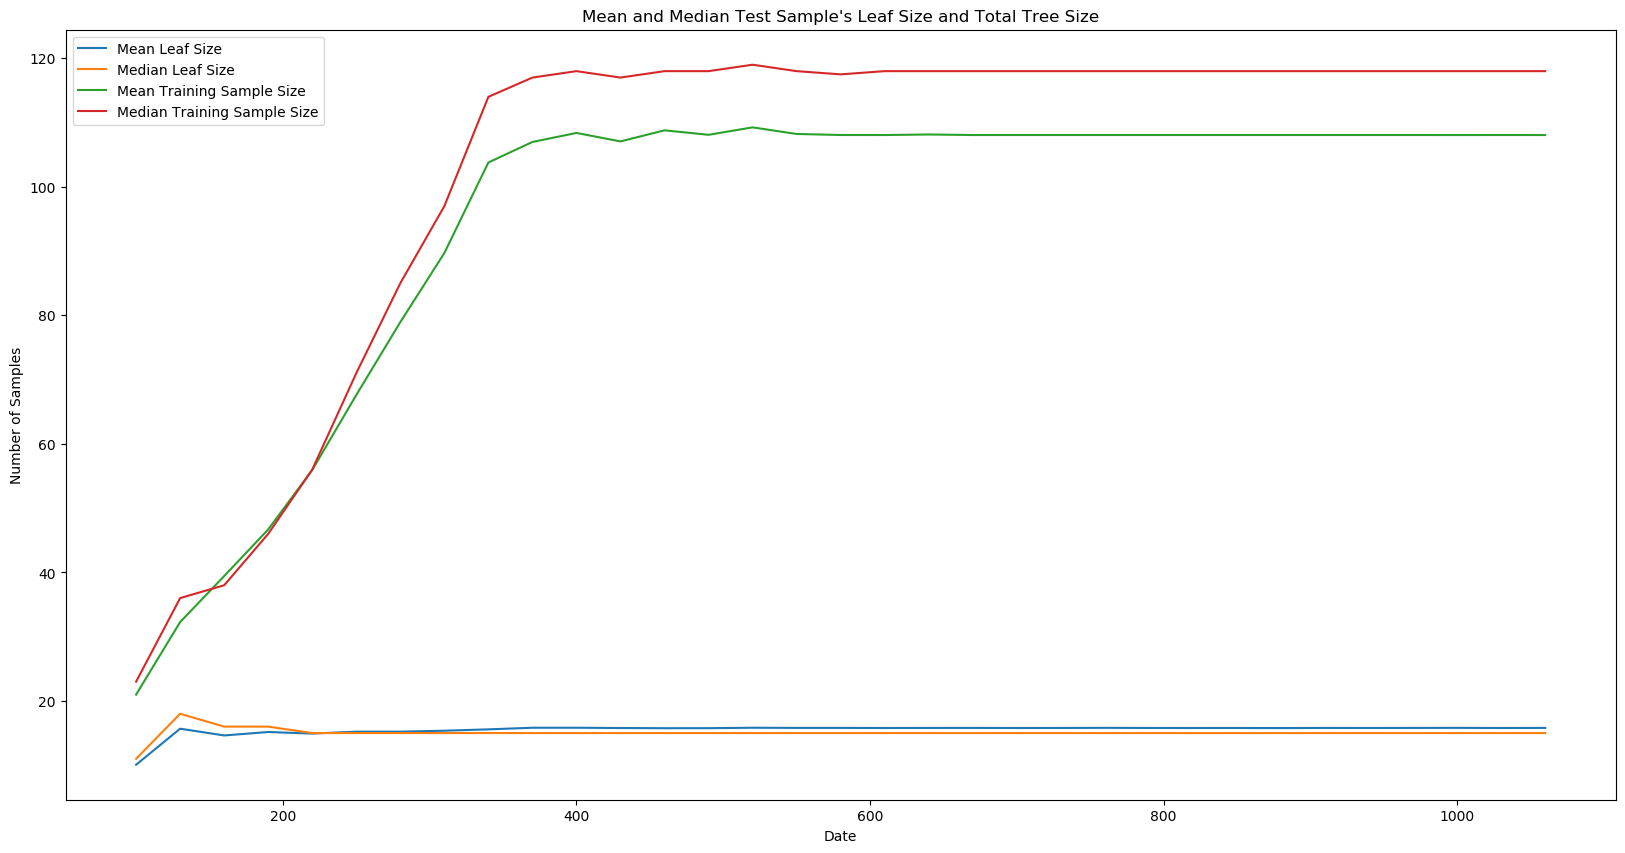

In [6]:
plt.figure(figsize=(20,10))
plt.plot(mean_leaf_size_by_cutoff, label="Mean Leaf Size")
plt.plot(median_leaf_size_by_cutoff, label="Median Leaf Size")

plt.plot(mean_sample_size_by_cutoff, label="Mean Training Sample Size")
plt.plot(median_sample_size_by_cutoff, label="Median Training Sample Size")

plt.xlabel("Date")
plt.ylabel("Number of Samples")
plt.title("Mean and Median Test Sample's Leaf Size and Total Tree Size")
plt.legend()

plt.show()

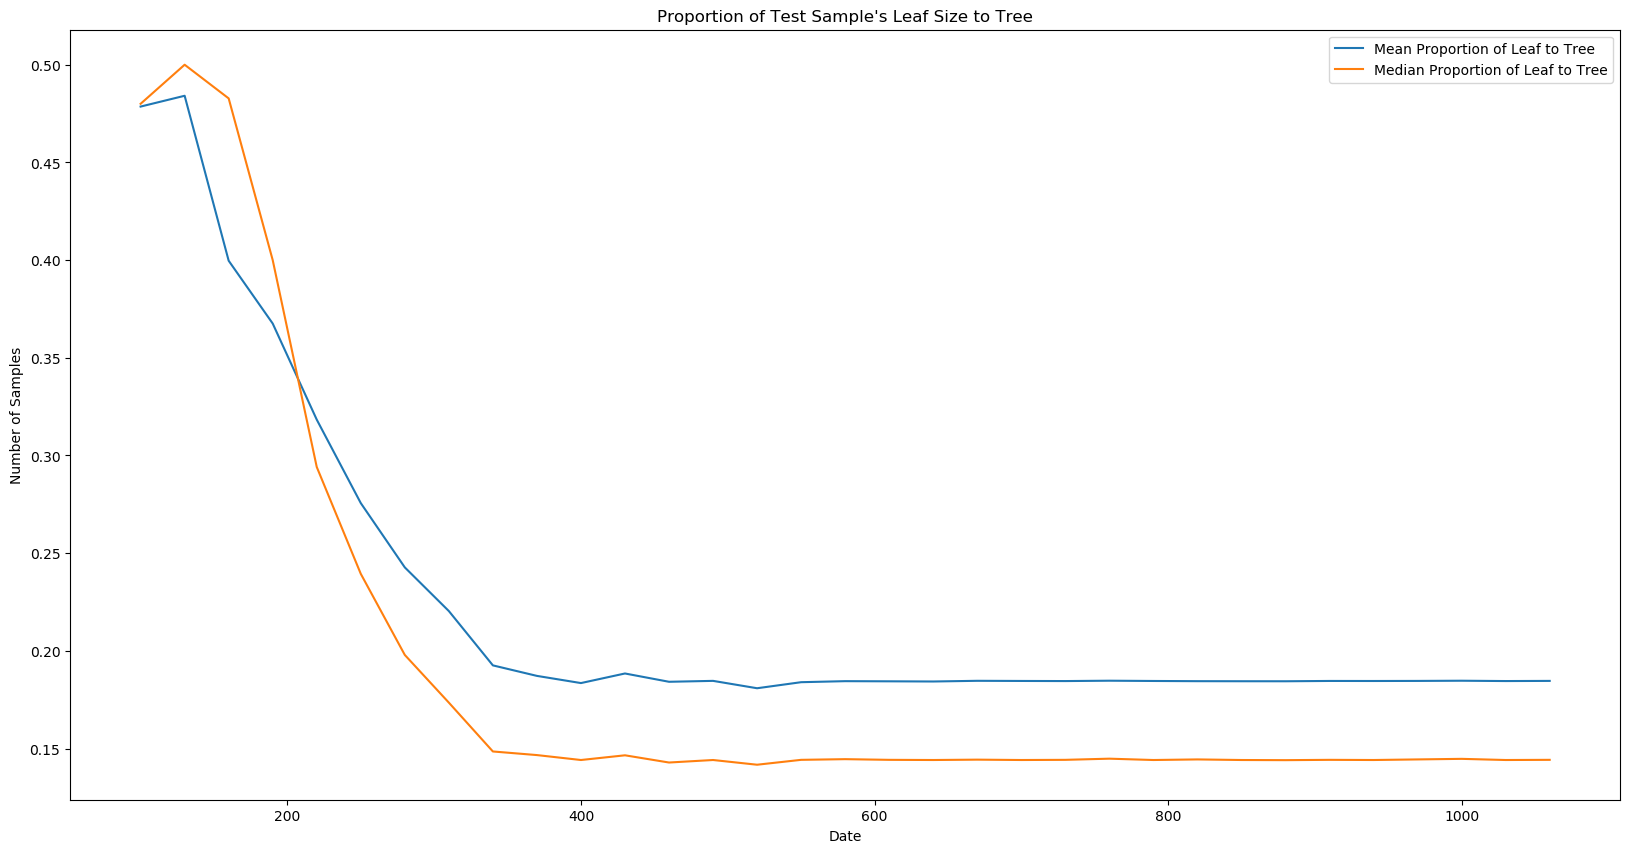

In [7]:
plt.figure(figsize=(20,10))
plt.plot(mean_ratio_by_cutoff, label="Mean Proportion of Leaf to Tree")
plt.plot(median_ratio_by_cutoff, label="Median Proportion of Leaf to Tree")
plt.xlabel("Date")
plt.ylabel("Number of Samples")
plt.title("Proportion of Test Sample's Leaf Size to Tree")
plt.legend()
plt.show()